### Importando dados

In [2]:
import pandas as pd

In [3]:
dolar = pd.read_csv("USD_BRL Dados Históricos.csv")
ouro = pd.read_csv("Dados Históricos - Ouro Futuros.csv")
vix = pd.read_csv("Dados Históricos - S&P 500 VIX.csv")
sep = pd.read_csv("Dados Históricos - S&P 500.csv")
ibov = pd.read_csv("Dados Históricos - Ibovespa.csv")

In [4]:
print(ibov.shape,sep.shape,vix.shape,ouro.shape,dolar.shape)

(2479, 7) (2516, 7) (2547, 7) (2564, 7) (2609, 7)


### Renomeando colunas

In [5]:
dolar.columns = ['Data', 'Último Dolar', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% Dolar']
ouro.columns = ['Data', 'Último Ouro', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% Ouro']
vix.columns = ['Data', 'Último Vix', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% Vix']
sep.columns = ['Data', 'Último S&P 500', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% S&P 500']
ibov.columns = ['Data', 'Último Ibovespa', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% Ibovespa']

In [6]:
df_completo = pd.merge(dolar[['Data', 'Var% Dolar']], ouro[['Data', 'Var% Ouro']], 
                       on="Data", how="inner")
df_completo = pd.merge(df_completo, vix[['Data', 'Var% Vix']], on="Data", how="inner")
df_completo = pd.merge(df_completo, sep[['Data', 'Var% S&P 500']], on="Data", how="inner")
df_completo = pd.merge(df_completo, ibov[['Data', 'Var% Ibovespa']], on="Data", how="inner")

In [7]:
df_completo

,Data,Var% Dolar,Var% Ouro,Var% Vix,Var% S&P 500,Var% Ibovespa
0,30.12.2024,"-0,30%","-0,01%","9,09%","-1,07%","0,01%"
1,27.12.2024,"0,22%","-0,83%","8,28%","-1,11%","-0,67%"
2,26.12.2024,"-0,13%","0,67%","3,22%","-0,04%","0,26%"
3,23.12.2024,"1,78%","-0,65%","-8,61%","0,73%","-1,09%"
4,20.12.2024,"-1,09%","1,41%","-23,79%","1,09%","0,75%"
...,...,...,...,...,...,...
2398,08.01.2015,"-0,78%","-0,18%","-11,91%","1,79%","0,97%"
2399,07.01.2015,"-0,61%","-0,71%","-8,57%","1,16%","3,05%"
2400,06.01.2015,"-0,23%","1,28%","6,02%","-0,89%","1,02%"
2401,05.01.2015,"0,48%","1,50%","11,97%","-1,83%","-2,05%"


In [8]:
# Tirando sinal de %

for i in df_completo.columns[1:]:
    df_completo[i] = pd.to_numeric(df_completo[i].str.replace('%', '', regex=False).str.replace(',', '.', regex=False),errors='coerce')


In [9]:
df = df_completo.copy()

In [10]:
df_completo["Ano"] = pd.to_datetime(df_completo['Data'], format='%d.%m.%Y').dt.year
df_completo = df_completo[df_completo["Ano"] < 2020]

### Estabelecendo correlação

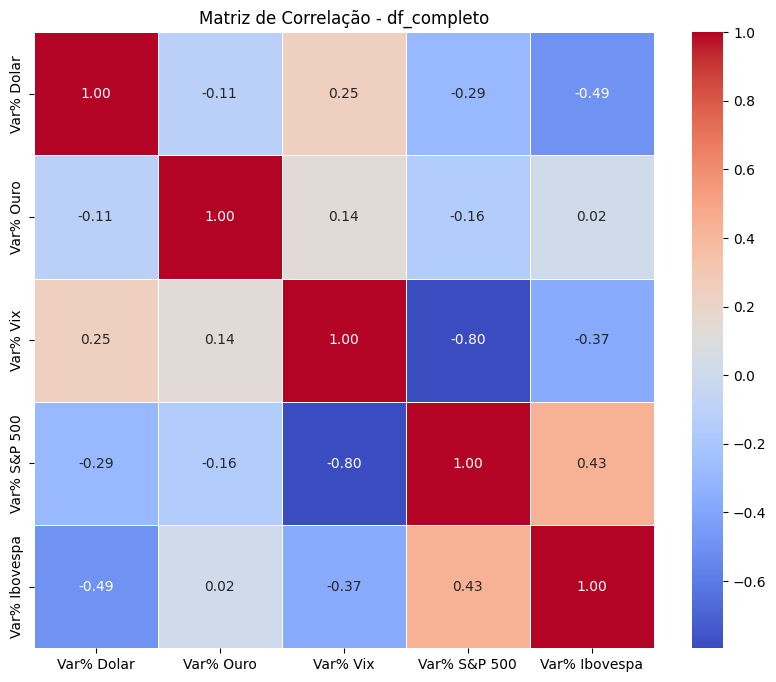

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a correlação entre as colunas do DataFrame
correlacao = df_completo[df_completo.columns[1:6]].corr()

# Plotando a matriz de correlação com Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação - df_completo')
plt.show()


C:\Users\rtorres.sae\AppData\Local\Temp\ipykernel_18048\2323273357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_completo.loc[:,"AnoMes"] = pd.to_datetime(df_completo['Data'], format='%d.%m.%Y').dt.to_period("M").astype(str)


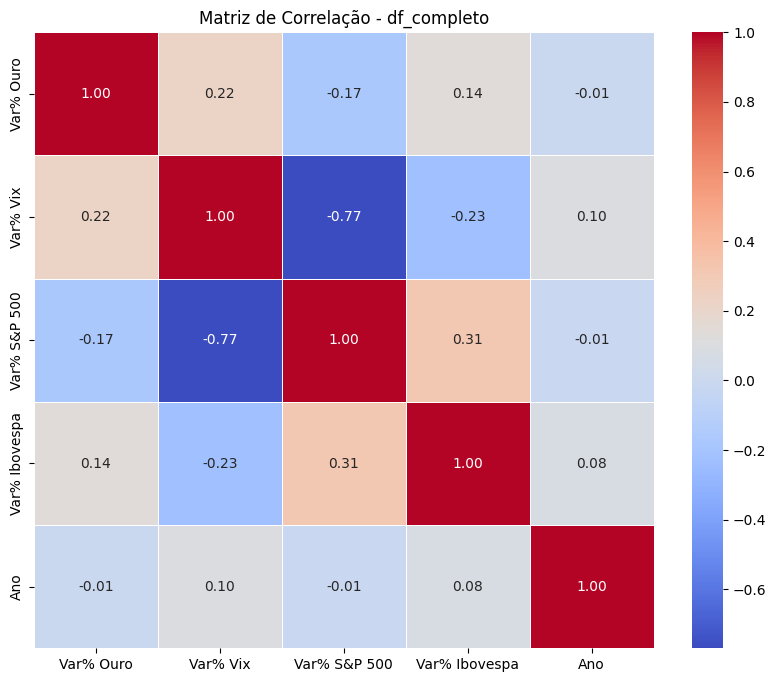

In [12]:

df_completo.loc[:,"AnoMes"] = pd.to_datetime(df_completo['Data'], format='%d.%m.%Y').dt.to_period("M").astype(str)

df_completo_mensal = df_completo.groupby("AnoMes")[df_completo.select_dtypes(include='number').columns].sum()

correlacao = df_completo_mensal.iloc[:, 1:6].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação - df_completo')
plt.show()


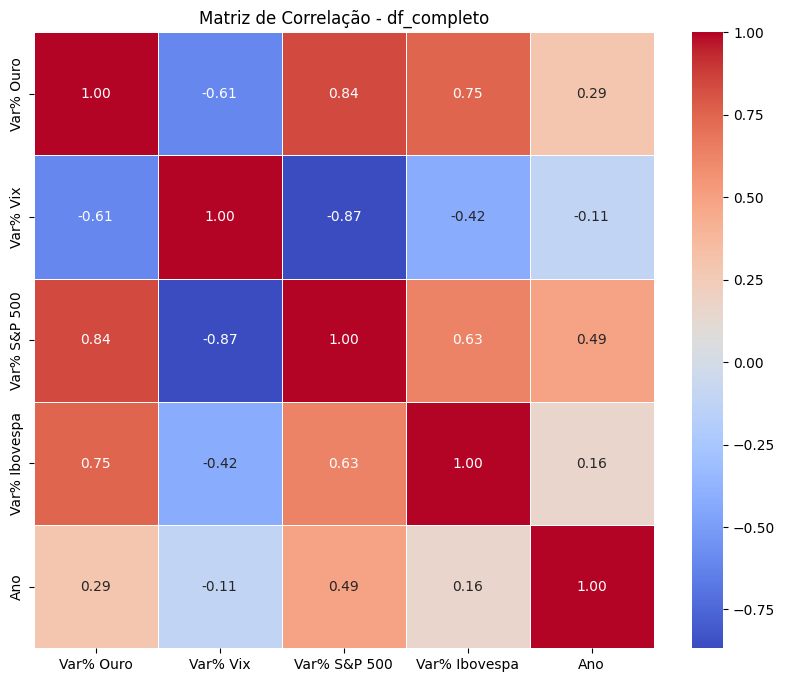

In [14]:

df_completo_mensal = df_completo.groupby("Ano")[df_completo.select_dtypes(include='number').columns].sum()

correlacao = df_completo_mensal.iloc[:, 1:6].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação - df_completo')
plt.show()

### Adicionando Volatilidade por período (Diário, Mensal, Anual).

In [85]:
df_dados = df_completo.copy()


In [ ]:
df_dados.rename(columns={
    'Var% Dolar': 'Dolar',
    'Var% Ouro': 'Ouro',
    'Var% Vix': 'VIX',
    'Var% S&P 500': 'S&P 500',
    'Var% Ibovespa': 'Ibovespa'
}, inplace=True)

indices = ['Dolar', 'Ouro', 'VIX', 'S&P 500', 'Ibovespa']
df_dados['Data'] = pd.to_datetime(df_dados['Data'], format='%d.%m.%Y')

retorno_diario = df_dados[indices].mean()
volatilidade_diaria = df_dados[indices].std()

retorno_mensal = df_dados.resample('ME', on='Data')[indices].mean().mean(axis=0)
volatilidade_mensal = df_dados.resample('ME', on='Data')[indices].std().mean(axis=0)

retorno_anual = df_dados.resample('YE', on='Data')[indices].mean().mean(axis=0)
volatilidade_anual = df_dados.resample('YE', on='Data')[indices].std().mean(axis=0)

df_final = pd.DataFrame({
    'Índice': indices,
    'Retorno Médio Diário': retorno_diario.values,
    'Volatilidade Diária': volatilidade_diaria.values,
    'Retorno Médio Mensal': retorno_mensal.values,
    'Volatilidade Mensal': volatilidade_mensal.values,
    'Retorno Médio Anual': retorno_anual.values,
    'Volatilidade Anual': volatilidade_anual.values
})

print(df_final)


     Índice  Retorno Médio Diário  Volatilidade Diária  Retorno Médio Mensal  \
0     Dolar              0.034424             1.054668              0.035169   
1      Ouro              0.033554             0.915770              0.032257   
2       VIX              0.237799             8.579894              0.231594   
3   S&P 500              0.059551             1.118130              0.060367   
4  Ibovespa              0.049026             1.519124              0.048094   

   Volatilidade Mensal  Retorno Médio Anual  Volatilidade Anual  
0             1.000470             0.034185            1.034847  
1             0.864025             0.033305            0.891946  
2             7.729744             0.238382            8.432027  
3             0.924629             0.059205            1.019066  
4             1.331396             0.049402            1.427477  


In [ ]:
### Vendo esses dados, o indice do "medo" o Vix tem a maior volatilidade, enquanto ouro um ativo históricamente estável tem a menor volatividade.
